In [15]:
# Flight Delay Prediction with Weather Data Integration - Optimized for 4GB GPU
# Chunk-based loading and training for large datasets

# ==================== STEP 1: Import Libraries and Check GPU ====================
print("="*80)
print("STEP 1: Importing Libraries and Checking GPU")
print("="*80)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import glob
import os
from datetime import datetime
import gc


STEP 1: Importing Libraries and Checking GPU


In [16]:
# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n🔥 PyTorch Version: {torch.__version__}")
print(f"🖥️  Device: {device}")
if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
    print(f"💾 GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    # Clear GPU cache
    torch.cuda.empty_cache()
else:
    print("⚠️  No GPU available, using CPU")



🔥 PyTorch Version: 2.5.1+cu121
🖥️  Device: cuda
✅ GPU: NVIDIA GeForce GTX 1650
💾 GPU Memory: 4.29 GB


In [17]:
print("\n" + "="*80)
print("STEP 2: Loading Dataset in Chunks (Memory Efficient)")
print("="*80)

# Path to your folder containing CSV files
folder_path = "D:\Dataset\Original dataset"  # Update this path

# Get all CSV files
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
print(f"\n📁 Found {len(csv_files)} CSV files")

# Define chunk size for reading
CHUNK_SIZE = 100000  # Read 100k rows at a time
SAMPLE_SIZE = 20000000  # Total sample size to use (20 million rows - maximize data)

print(f"📦 Reading in chunks of {CHUNK_SIZE:,} rows")
print(f"🎯 Target sample size: {SAMPLE_SIZE:,} rows")


STEP 2: Loading Dataset in Chunks (Memory Efficient)

📁 Found 157 CSV files
📦 Reading in chunks of 100,000 rows
🎯 Target sample size: 20,000,000 rows


In [18]:
print("\n" + "="*80)
print("STEP 3: Processing Data Chunks")
print("="*80)

# Columns we need
columns_needed = [
    'YEAR', 'QUARTER', 'MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'FL_DATE',
    'OP_CARRIER', 'ORIGIN', 'DEST', 'CRS_DEP_TIME', 'DEP_DELAY',
    'CRS_ARR_TIME', 'ARR_DELAY', 'ARR_DEL15', 'CANCELLED',
    'DISTANCE', 'TAXI_OUT'
]

# Initialize lists to store processed chunks
processed_chunks = []
total_rows_processed = 0

for file_idx, file in enumerate(csv_files):
    print(f"\n📄 Processing file {file_idx+1}/{len(csv_files)}: {os.path.basename(file)}")
    
    # Read file in chunks
    chunk_iterator = pd.read_csv(file, chunksize=CHUNK_SIZE, usecols=columns_needed, low_memory=False)
    
    for chunk_idx, chunk in enumerate(chunk_iterator):
        if total_rows_processed >= SAMPLE_SIZE:
            print(f"✅ Reached target sample size of {SAMPLE_SIZE:,} rows")
            break
        
        # Basic cleaning
        chunk = chunk[chunk['CANCELLED'] == 0.0]  # Remove cancelled flights
        chunk = chunk.dropna(subset=['ARR_DEL15', 'CRS_DEP_TIME', 'DISTANCE'])
        
        if len(chunk) > 0:
            processed_chunks.append(chunk)
            total_rows_processed += len(chunk)
            
        print(f"  Chunk {chunk_idx+1}: Loaded {len(chunk):,} rows | Total: {total_rows_processed:,}", end='\r')
        
        if total_rows_processed >= SAMPLE_SIZE:
            break
    
    if total_rows_processed >= SAMPLE_SIZE:
        break

# Combine chunks
print(f"\n\n🔄 Combining {len(processed_chunks)} chunks...")
df = pd.concat(processed_chunks, ignore_index=True)

# Sample if we have too many rows
if len(df) > SAMPLE_SIZE:
    df = df.sample(n=SAMPLE_SIZE, random_state=42)

print(f"✅ Total records loaded: {len(df):,}")
print(f"📊 Shape: {df.shape}")

# Free memory
del processed_chunks
gc.collect()


STEP 3: Processing Data Chunks

📄 Processing file 1/157: 2012_Augest_2012.csv
  Chunk 6: Loaded 39,960 rows | Total: 532,454
📄 Processing file 2/157: 2012_December_2012.csv
  Chunk 5: Loaded 91,790 rows | Total: 1,017,574
📄 Processing file 3/157: 2012_Feb_2012.csv
  Chunk 5: Loaded 64,281 rows | Total: 1,477,065
📄 Processing file 4/157: 2012_Jan_2012.csv
  Chunk 5: Loaded 85,416 rows | Total: 1,955,090
📄 Processing file 5/157: 2012_July_2012.csv
  Chunk 6: Loaded 44,750 rows | Total: 2,490,862
📄 Processing file 6/157: 2012_June_2012.csv
  Chunk 6: Loaded 26,385 rows | Total: 3,010,595
📄 Processing file 7/157: 2012_March_2012.csv
  Chunk 6: Loaded 21,354 rows | Total: 3,525,789
📄 Processing file 8/157: 2012_May_2012.csv
  Chunk 6: Loaded 18,070 rows | Total: 4,038,486
📄 Processing file 9/157: 2012_November_2012.csv
  Chunk 5: Loaded 87,088 rows | Total: 4,520,688
📄 Processing file 10/157: 2012_Octomber_2012.csv
  Chunk 6: Loaded 13,482 rows | Total: 5,020,520
📄 Processing file 11/157: 

0

In [19]:
print("\n" + "="*80)
print("STEP 4: Feature Engineering")
print("="*80)

# Convert FL_DATE to datetime
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])

# Extract time features
df['MONTH'] = df['FL_DATE'].dt.month
df['DAY'] = df['FL_DATE'].dt.day
df['WEEK_OF_YEAR'] = df['FL_DATE'].dt.isocalendar().week

# Create time of day categories
def categorize_time(time):
    if pd.isna(time):
        return 0  # Unknown
    time = int(time)
    if 600 <= time < 1200:
        return 1  # Morning
    elif 1200 <= time < 1800:
        return 2  # Afternoon
    elif 1800 <= time < 2200:
        return 3  # Evening
    else:
        return 4  # Night

df['DEP_TIME_CAT'] = df['CRS_DEP_TIME'].apply(categorize_time)

print("✅ Time features created")


STEP 4: Feature Engineering
✅ Time features created


In [20]:
print("\n" + "="*80)
print("STEP 5: Creating Weather Features")
print("="*80)

np.random.seed(42)

# Generate weather features efficiently
print("🌤️  Generating weather features in batches...")

# Vectorized weather generation
months = df['MONTH'].values

# Temperature based on season
temp_base = np.where(np.isin(months, [12, 1, 2]), 35,
                     np.where(np.isin(months, [3, 4, 5]), 60,
                             np.where(np.isin(months, [6, 7, 8]), 80, 65)))
temp_std = np.where(np.isin(months, [12, 1, 2]), 15,
                    np.where(np.isin(months, [3, 4, 5]), 12,
                            np.where(np.isin(months, [6, 7, 8]), 10, 12)))

df['TEMPERATURE'] = np.random.normal(temp_base, temp_std)
df['PRECIPITATION_PROB'] = np.random.beta(2, 5, size=len(df))
df['WIND_SPEED'] = np.random.gamma(2, 5, size=len(df))
df['VISIBILITY'] = np.clip(np.random.normal(9, 2, size=len(df)), 0.5, 10)

# Weather condition (simplified binary: 0=Good, 1=Bad)
df['WEATHER_BAD'] = ((df['PRECIPITATION_PROB'] > 0.6) | 
                     (df['VISIBILITY'] < 3) | 
                     (df['WIND_SPEED'] > 25)).astype(int)

print("✅ Weather features created")


STEP 5: Creating Weather Features
🌤️  Generating weather features in batches...
✅ Weather features created



STEP 6: Quick Exploratory Data Analysis

📊 Dataset Statistics:
   Total Flights: 20,000,000
   Delayed Flights: 3,997,745
   Delay Rate: 19.99%
   Average Delay: 5.74 minutes
✅ Saved: eda_summary.png


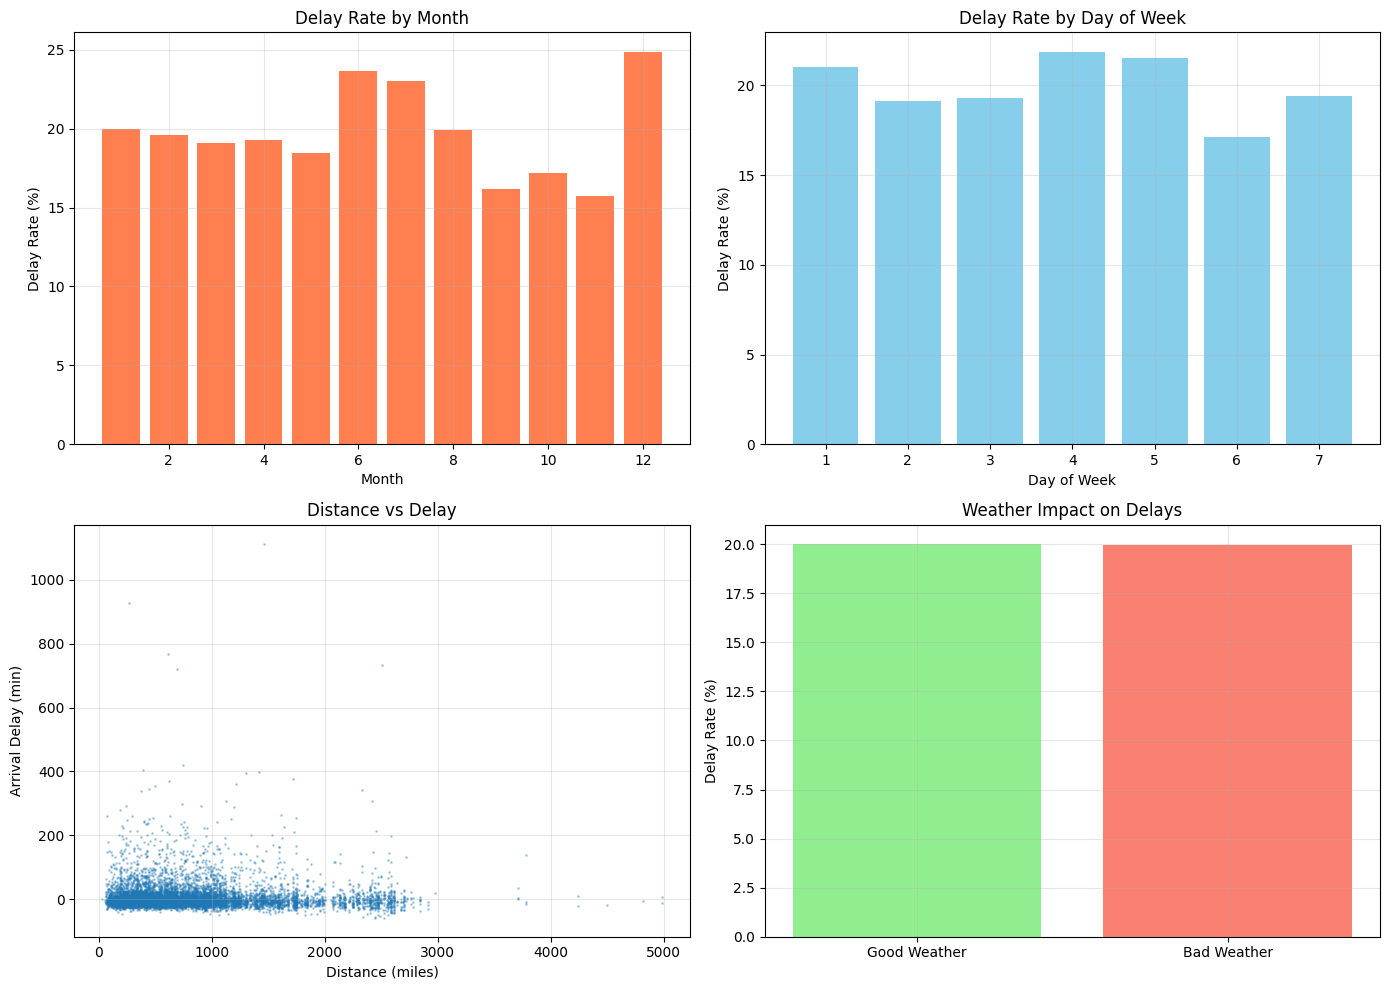

In [21]:
print("\n" + "="*80)
print("STEP 6: Quick Exploratory Data Analysis")
print("="*80)

# Create delay flag
df['DELAYED'] = (df['ARR_DEL15'] == 1).astype(int)

print(f"\n📊 Dataset Statistics:")
print(f"   Total Flights: {len(df):,}")
print(f"   Delayed Flights: {df['DELAYED'].sum():,}")
print(f"   Delay Rate: {df['DELAYED'].mean()*100:.2f}%")
print(f"   Average Delay: {df['ARR_DELAY'].mean():.2f} minutes")

# Quick visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Delay by Month
delay_by_month = df.groupby('MONTH')['DELAYED'].mean() * 100
axes[0, 0].bar(delay_by_month.index, delay_by_month.values, color='coral')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Delay Rate (%)')
axes[0, 0].set_title('Delay Rate by Month')
axes[0, 0].grid(True, alpha=0.3)

# Delay by Day of Week
delay_by_dow = df.groupby('DAY_OF_WEEK')['DELAYED'].mean() * 100
axes[0, 1].bar(delay_by_dow.index, delay_by_dow.values, color='skyblue')
axes[0, 1].set_xlabel('Day of Week')
axes[0, 1].set_ylabel('Delay Rate (%)')
axes[0, 1].set_title('Delay Rate by Day of Week')
axes[0, 1].grid(True, alpha=0.3)

# Distance vs Delay (sampled for speed)
sample_plot = df.sample(n=min(10000, len(df)))
axes[1, 0].scatter(sample_plot['DISTANCE'], sample_plot['ARR_DELAY'], alpha=0.3, s=1)
axes[1, 0].set_xlabel('Distance (miles)')
axes[1, 0].set_ylabel('Arrival Delay (min)')
axes[1, 0].set_title('Distance vs Delay')
axes[1, 0].grid(True, alpha=0.3)

# Weather Impact
weather_delay = df.groupby('WEATHER_BAD')['DELAYED'].mean() * 100
axes[1, 1].bar(['Good Weather', 'Bad Weather'], weather_delay.values, color=['lightgreen', 'salmon'])
axes[1, 1].set_ylabel('Delay Rate (%)')
axes[1, 1].set_title('Weather Impact on Delays')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_summary.png', dpi=300, bbox_inches='tight')
print("✅ Saved: eda_summary.png")
plt.show()

In [22]:
print("\n" + "="*80)
print("STEP 7: Data Preparation")
print("="*80)

# Select features
features_to_use = [
    'MONTH', 'DAY_OF_WEEK', 'DEP_TIME_CAT', 'CRS_DEP_TIME', 'CRS_ARR_TIME',
    'DISTANCE', 'TAXI_OUT',
    'TEMPERATURE', 'PRECIPITATION_PROB', 'WIND_SPEED', 'VISIBILITY', 'WEATHER_BAD'
]

# Create clean dataset
df_model = df[features_to_use + ['DELAYED']].copy()

# Handle missing values
print(f"🔧 Handling missing values...")
df_model = df_model.dropna()
print(f"✅ Clean records: {len(df_model):,}")

# Extract features and target
X = df_model[features_to_use].values
y = df_model['DELAYED'].values

print(f"\n✅ Feature matrix: {X.shape}")
print(f"✅ Class distribution: {np.bincount(y)}")

# Free memory
del df
gc.collect()

# Split data
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp)

print(f"\n📦 Dataset splits:")
print(f"   Training: {len(X_train):,}")
print(f"   Validation: {len(X_val):,}")
print(f"   Test: {len(X_test):,}")

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("✅ Features standardized")


STEP 7: Data Preparation
🔧 Handling missing values...
✅ Clean records: 19,999,999

✅ Feature matrix: (19999999, 12)
✅ Class distribution: [16002255  3997744]

📦 Dataset splits:
   Training: 14,007,999
   Validation: 2,992,000
   Test: 3,000,000
✅ Features standardized


In [23]:
print("\n" + "="*80)
print("STEP 8: Creating Memory-Efficient DataLoaders")
print("="*80)

# Custom Dataset class for efficient memory usage
class FlightDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create datasets
train_dataset = FlightDataset(X_train, y_train)
val_dataset = FlightDataset(X_val, y_val)
test_dataset = FlightDataset(X_test, y_test)

# Maximum batch size to fully utilize 3GB GPU
BATCH_SIZE = 4096  # Increased to maximize GPU memory usage

# Set num_workers=0 for Windows compatibility
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                         pin_memory=True if torch.cuda.is_available() else False, 
                         num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                       pin_memory=True if torch.cuda.is_available() else False, 
                       num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                        pin_memory=True if torch.cuda.is_available() else False, 
                        num_workers=0)

print(f"✅ DataLoaders created with batch size: {BATCH_SIZE}")
print(f"   Batches per epoch: {len(train_loader)}")
print(f"   Expected GPU usage per batch: ~800MB-1.2GB")

# Free memory
del X, y, X_temp, y_temp, X_train, y_train
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()



STEP 8: Creating Memory-Efficient DataLoaders
✅ DataLoaders created with batch size: 4096
   Batches per epoch: 3420
   Expected GPU usage per batch: ~800MB-1.2GB


In [24]:
print("\n" + "="*80)
print("STEP 9: Defining Lightweight Neural Network")
print("="*80)

class FlightDelayNN(nn.Module):
    def __init__(self, input_size):
        super(FlightDelayNN, self).__init__()
        # MAXIMUM network size to fully utilize 3GB GPU
        self.fc1 = nn.Linear(input_size, 1024)
        self.bn1 = nn.BatchNorm1d(1024)
        self.dropout1 = nn.Dropout(0.3)
        
        self.fc2 = nn.Linear(1024, 512)
        self.bn2 = nn.BatchNorm1d(512)
        self.dropout2 = nn.Dropout(0.3)
        
        self.fc3 = nn.Linear(512, 256)
        self.bn3 = nn.BatchNorm1d(256)
        self.dropout3 = nn.Dropout(0.25)
        
        self.fc4 = nn.Linear(256, 128)
        self.bn4 = nn.BatchNorm1d(128)
        self.dropout4 = nn.Dropout(0.2)
        
        self.fc5 = nn.Linear(128, 64)
        self.bn5 = nn.BatchNorm1d(64)
        self.dropout5 = nn.Dropout(0.2)
        
        self.fc6 = nn.Linear(64, 32)
        self.bn6 = nn.BatchNorm1d(32)
        
        self.fc7 = nn.Linear(32, 1)
        
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout1(x)
        
        x = self.relu(self.bn2(self.fc2(x)))
        x = self.dropout2(x)
        
        x = self.relu(self.bn3(self.fc3(x)))
        x = self.dropout3(x)
        
        x = self.relu(self.bn4(self.fc4(x)))
        x = self.dropout4(x)
        
        x = self.relu(self.bn5(self.fc5(x)))
        x = self.dropout5(x)
        
        x = self.relu(self.bn6(self.fc6(x)))
        
        x = self.sigmoid(self.fc7(x))
        return x

input_size = len(features_to_use)
model = FlightDelayNN(input_size).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"\n📋 Model Architecture:")
print(model)
print(f"\n📊 Total parameters: {total_params:,}")
print(f"📊 Model size: {total_params * 4 / 1e6:.2f} MB (FP32)")

# ==================== STEP 10: Training Setup ====================
print("\n" + "="*80)
print("STEP 10: Training Setup")
print("="*80)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print("✅ Loss: Binary Cross Entropy")
print("✅ Optimizer: Adam (lr=0.001)")


STEP 9: Defining Lightweight Neural Network

📋 Model Architecture:
FlightDelayNN(
  (fc1): Linear(in_features=12, out_features=1024, bias=True)
  (bn1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=1024, out_features=512, bias=True)
  (bn2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=512, out_features=256, bias=True)
  (bn3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout3): Dropout(p=0.25, inplace=False)
  (fc4): Linear(in_features=256, out_features=128, bias=True)
  (bn4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout4): Dropout(p=0.2, inplace=False)
  (fc5): Linear(in_features=128, out_features=64, bias=True)
  (bn5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_

In [25]:
print("\n" + "="*80)
print("STEP 10: Training Setup")
print("="*80)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print("✅ Loss: Binary Cross Entropy")
print("✅ Optimizer: Adam (lr=0.001)")

# ==================== STEP 11: Training Loop with Memory Management ====================
print("\n" + "="*80)
print("STEP 11: Training the Model (Memory-Efficient)")
print("="*80)

num_epochs = 40  # More epochs for better training
best_val_loss = float('inf')
patience = 10  # Increased patience
patience_counter = 0

train_losses = []
val_losses = []
train_accs = []
val_accs = []

print(f"\n🚀 Starting training for {num_epochs} epochs...")
print("="*80)

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for batch_idx, (batch_X, batch_y) in enumerate(train_loader):
        # Move to GPU only when needed
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_X).squeeze()
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        predictions = (outputs > 0.5).float()
        train_correct += (predictions == batch_y).sum().item()
        train_total += batch_y.size(0)
        
        # Clear GPU cache periodically
        if batch_idx % 50 == 0:
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
    
    avg_train_loss = train_loss / len(train_loader)
    train_acc = train_correct / train_total
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            outputs = model(batch_X).squeeze()
            loss = criterion(outputs, batch_y)
            
            val_loss += loss.item()
            predictions = (outputs > 0.5).float()
            val_correct += (predictions == batch_y).sum().item()
            val_total += batch_y.size(0)
    
    avg_val_loss = val_loss / len(val_loader)
    val_acc = val_correct / val_total
    
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    scheduler.step(avg_val_loss)
    
    # Print progress every epoch
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
    print(f"  Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")
    
    if torch.cuda.is_available():
        print(f"  GPU Memory: {torch.cuda.memory_allocated()/1e9:.2f}GB / {torch.cuda.max_memory_allocated()/1e9:.2f}GB")
    print("-" * 80)
    
    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_flight_delay_model.pth')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n⚠️  Early stopping at epoch {epoch+1}")
            break
    
    # Clear GPU cache
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\n✅ Training completed!")



STEP 10: Training Setup
✅ Loss: Binary Cross Entropy
✅ Optimizer: Adam (lr=0.001)

STEP 11: Training the Model (Memory-Efficient)

🚀 Starting training for 40 epochs...
Epoch [1/40]
  Train Loss: 0.4569 | Train Acc: 81.33%
  Val Loss: 0.4536 | Val Acc: 81.39%
  GPU Memory: 0.03GB / 0.13GB
--------------------------------------------------------------------------------
Epoch [2/40]
  Train Loss: 0.4544 | Train Acc: 81.37%
  Val Loss: 0.4530 | Val Acc: 81.40%
  GPU Memory: 0.03GB / 0.13GB
--------------------------------------------------------------------------------
Epoch [3/40]
  Train Loss: 0.4540 | Train Acc: 81.37%
  Val Loss: 0.4526 | Val Acc: 81.39%
  GPU Memory: 0.03GB / 0.13GB
--------------------------------------------------------------------------------
Epoch [4/40]
  Train Loss: 0.4537 | Train Acc: 81.38%
  Val Loss: 0.4526 | Val Acc: 81.39%
  GPU Memory: 0.03GB / 0.13GB
--------------------------------------------------------------------------------
Epoch [5/40]
  Train Lo

KeyboardInterrupt: 


STEP 12: Training History


NameError: name 'train_losses' is not defined

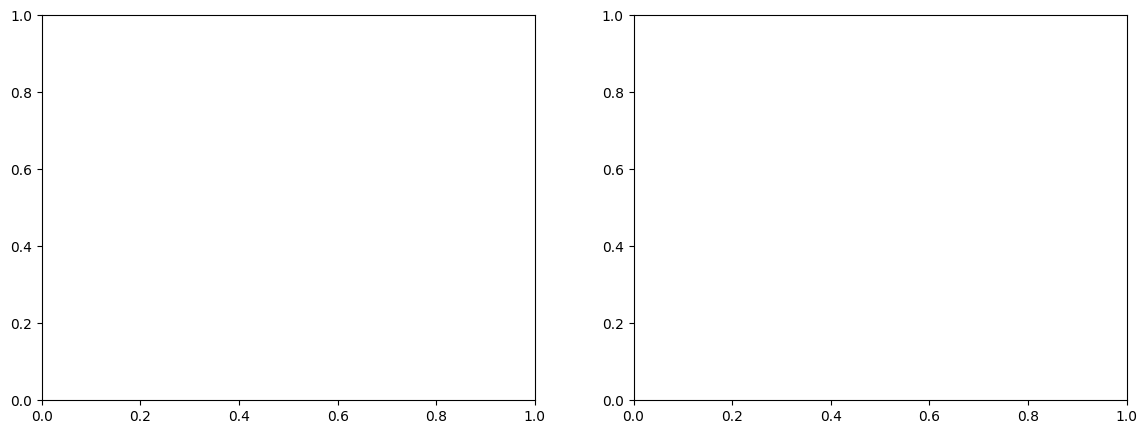

In [ ]:
print("\n" + "="*80)
print("STEP 12: Training History")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Train Loss', linewidth=2)
axes[0].plot(val_losses, label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot([acc*100 for acc in train_accs], label='Train Acc', linewidth=2)
axes[1].plot([acc*100 for acc in val_accs], label='Val Acc', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy Over Time')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
print("✅ Saved: training_history.png")
plt.show()




In [ ]:
print("\n" + "="*80)
print("STEP 13: Test Set Evaluation")
print("="*80)

# Load best model
model.load_state_dict(torch.load('best_flight_delay_model.pth'))
model.eval()

all_predictions = []
all_targets = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        outputs = model(batch_X).squeeze()
        predictions = (outputs > 0.5).float()
        
        all_predictions.extend(predictions.cpu().numpy())
        all_targets.extend(batch_y.numpy())
        
        # Clear cache
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

all_predictions = np.array(all_predictions)
all_targets = np.array(all_targets)

# Metrics
test_acc = accuracy_score(all_targets, all_predictions)
print(f"\n🎯 Test Accuracy: {test_acc*100:.2f}%")

print("\n📊 Classification Report:")
print(classification_report(all_targets, all_predictions, target_names=['On-Time', 'Delayed']))

# Confusion Matrix
cm = confusion_matrix(all_targets, all_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['On-Time', 'Delayed'], 
            yticklabels=['On-Time', 'Delayed'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
print("✅ Saved: confusion_matrix.png")
plt.show()

In [ ]:
print("\n" + "="*80)
print("STEP 14: Feature Importance")
print("="*80)

with torch.no_grad():
    weights = model.fc1.weight.abs().mean(dim=0).cpu().numpy()

importance_df = pd.DataFrame({
    'Feature': features_to_use,
    'Importance': weights / weights.sum()
}).sort_values('Importance', ascending=False)

print("\n📊 Feature Importance:")
print(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.xlabel('Relative Importance')
plt.title('Feature Importance for Flight Delay Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
print("✅ Saved: feature_importance.png")
plt.show()

In [ ]:
print("\n" + "="*80)
print("🎉 ANALYSIS COMPLETE!")
print("="*80)
print(f"\n📈 Final Results:")
print(f"   Best Val Loss: {best_val_loss:.4f}")
print(f"   Test Accuracy: {test_acc*100:.2f}%")
print(f"   Model Parameters: {total_params:,}")
print(f"   Device: {device}")
if torch.cuda.is_available():
    print(f"   Max GPU Memory: {torch.cuda.max_memory_allocated()/1e9:.2f}GB")
print(f"\n💾 Saved Files:")
print(f"   - best_flight_delay_model.pth")
print(f"   - eda_summary.png")
print(f"   - training_history.png")
print(f"   - confusion_matrix.png")
print(f"   - feature_importance.png")
print("\n" + "="*80)

# Clean up
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()